In [2]:
import pandas as pd

def read_csv_to_dataframe(file_path: str) -> pd.DataFrame:
    try:
        df = pd.read_csv(file_path)
        return df
    except Exception as e:
        print(f"Error reading CSV file: {e}")
        return pd.DataFrame()

In [13]:
Rosedata_df = read_csv_to_dataframe("Event_core_v4.csv")

In [14]:
print(Rosedata_df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29 entries, 0 to 28
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   event_date                    29 non-null     object 
 1   event_id                      29 non-null     object 
 2   parent_event_id               29 non-null     object 
 3   type                          29 non-null     object 
 4   location_id                   29 non-null     object 
 5   decimal_latitud               29 non-null     float64
 6   decimal_longitude             29 non-null     float64
 7   depth_m                       29 non-null     int64  
 8   habitat                       29 non-null     object 
 9   conteo_ind                    29 non-null     int64  
 10  temperat_grad_c               29 non-null     float64
 11  total_organic_matter_percent  29 non-null     float64
 12  proport_silt_clay_percent     29 non-null     int64  
 13  prop_si

* Mann Whitney U test:

In [15]:
from scipy.stats import mannwhitneyu

def mann_whitney_test(data1, data2, alpha=0.05):
    """
    Performs the Mann-Whitney U test and prints U statistic, p-value, and result.
    """
    result = mannwhitneyu(data1, data2, alternative='two-sided')
    
    print(f"U statistic = {result.statistic}")
    print(f"p-value = {result.pvalue}")

    if result.pvalue < alpha:
        print("The difference is statistically significant.")
    else:
        print("The difference is not statistically significant.")

##### 1ero veré mis datos de temperatura en un boxplot:

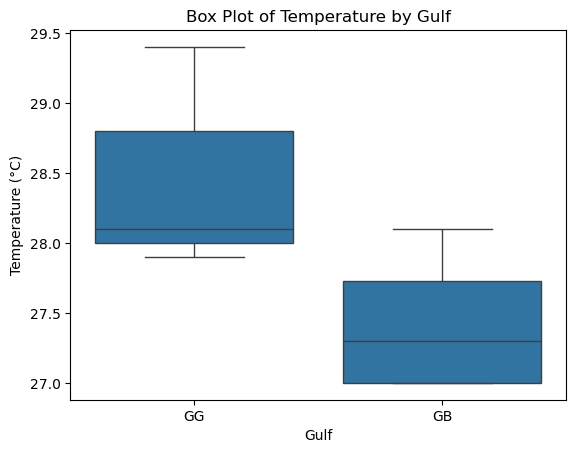

In [16]:
# Plot the box plot of Temperature by gulf
import seaborn as sns
import matplotlib.pyplot as plt

# Create a box plot
sns.boxplot(x='parent_event_id', y='temperat_grad_c', data=Rosedata_df)
#sns.swarmplot(x='gulf', y='temperature', data=Rosedata_df, color=".25")

# Add labels and title
plt.xlabel('Gulf')
plt.ylabel('Temperature (°C)')
plt.title('Box Plot of Temperature by Gulf')

# Show the plot
plt.show()

Prueba de Mann-Whitney para temperatura
* Resultado: Hay diferencias significativas.

In [17]:
# Filter the Temperature data by Gulf
temp_GG = Rosedata_df.loc[Rosedata_df["parent_event_id"] == "GG", "temperat_grad_c"]
temp_GB = Rosedata_df.loc[Rosedata_df["parent_event_id"] == "GB", "temperat_grad_c"]

# Perform the Mann-Whitney U test for TA between dry and rainy seasons
mann_whitney_test(temp_GG, temp_GB)

U statistic = 180.0
p-value = 0.0005037146895883388
The difference is statistically significant.


Plot de violin para temperatura:

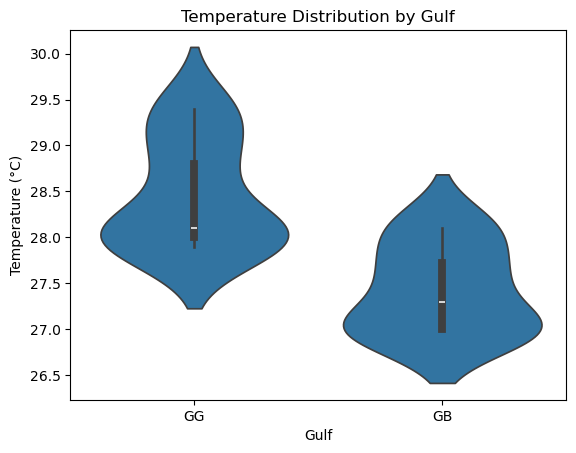

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt


# Create a box plot
sns.violinplot(x='parent_event_id', y='temperat_grad_c', data=Rosedata_df)

plt.title('Temperature Distribution by Gulf')
plt.xlabel('Gulf')
plt.ylabel('Temperature (°C)')
plt.show()

##### 2do veré mis datos de TOM en un boxplot:

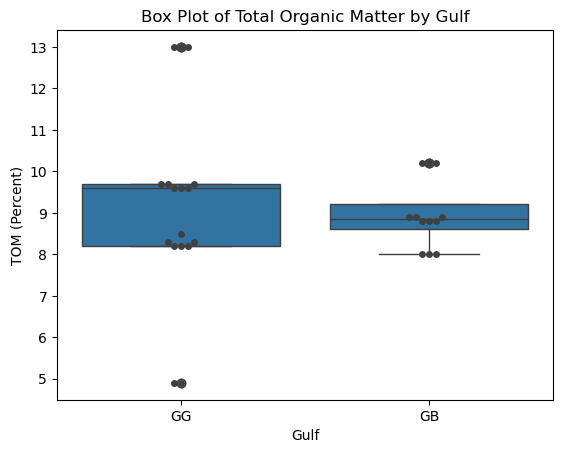

In [18]:
# Plot the box plot of TOM by gulf
import seaborn as sns
import matplotlib.pyplot as plt

# Create a box plot
sns.boxplot(x='parent_event_id', y='total_organic_matter_percent', data=Rosedata_df)
sns.swarmplot(x='parent_event_id', y='total_organic_matter_percent', data=Rosedata_df, color=".25")

# Add labels and title
plt.xlabel('Gulf')
plt.ylabel('TOM (Percent)')
plt.title('Box Plot of Total Organic Matter by Gulf')

# Show the plot
plt.show()

Prueba Mann-Whitney para TOM
* Resultado: No hay diferencias significativas.

In [19]:
# Filter the TOM data by Gulf
tom_GG = Rosedata_df.loc[Rosedata_df["parent_event_id"] == "GG", "total_organic_matter_percent"]
tom_GB = Rosedata_df.loc[Rosedata_df["parent_event_id"] == "GB", "total_organic_matter_percent"]

# Perform the Mann-Whitney U test for TA between dry and rainy seasons
mann_whitney_test(tom_GG, tom_GB)

U statistic = 108.0
p-value = 0.8067891556470117
The difference is not statistically significant.


Plot de violin para TOM:

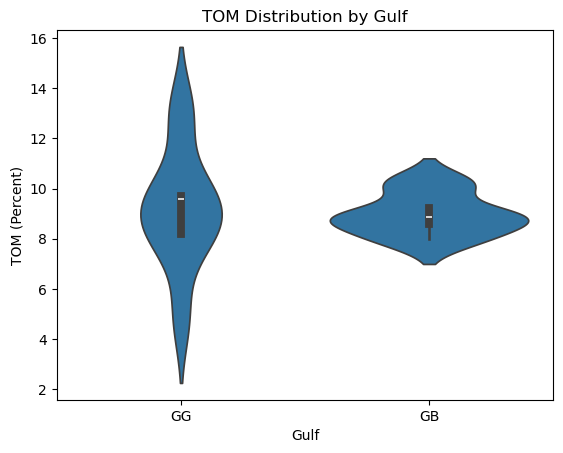

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt


# Create a box plot
sns.violinplot(x='parent_event_id', y='total_organic_matter_percent', data=Rosedata_df)

plt.title('TOM Distribution by Gulf')
plt.xlabel('Gulf')
plt.ylabel('TOM (Percent)')
plt.show()